# **Assignment 0 — Task 1: Inner Workings of ResNet-152**

In [4]:
import os
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.manifold import TSNE
import seaborn as sns

import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
from sklearn.metrics.pairwise import cosine_similarity


# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cuda


In [5]:

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUN_DIR = '/content/drive/MyDrive/ATML/assignment_00/task1_resnet152'
except ImportError:
    RUN_DIR = './task1_resnet152'  # not on Colab

os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(f'{RUN_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{RUN_DIR}/features', exist_ok=True)
DATA_ROOT = f'{RUN_DIR}/data'
TORCH_HOME = f'{RUN_DIR}/torch_cache'
os.environ['TORCH_HOME'] = TORCH_HOME

DRY_RUN = False
SUBSET_TRAIN = 512 if DRY_RUN else 8000
SUBSET_EVAL = 256 if DRY_RUN else 2000
NUM_EPOCHS = 1 if DRY_RUN else 5

print(f"RUN_DIR={RUN_DIR}")
print(f"DRY_RUN={DRY_RUN} | train={SUBSET_TRAIN} eval={SUBSET_EVAL} epochs={NUM_EPOCHS}")

def save_checkpoint(state_dict, name):
    path = f'{RUN_DIR}/checkpoints/{name}.pt'
    torch.save(state_dict, path)
    print(f"saved -> {path}")

def load_checkpoint(name, map_location=None):
    path = f'{RUN_DIR}/checkpoints/{name}.pt'
    return torch.load(path, map_location=map_location or DEVICE) if os.path.exists(path) else None

Mounted at /content/drive
RUN_DIR=/content/drive/MyDrive/ATML/assignment_00/task1_resnet152
DRY_RUN=False | train=8000 eval=2000 epochs=5


## 1. Baseline Setup
(a) Use a pre-trained ResNet-152 from PyTorch.

(b) Replace the final classification layer to match a smaller dataset such as CIFAR-10.

(c) Train only the classification head while freezing the rest of the backbone.

(d) Record training and validation performance for a few epochs.

In [6]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

resnet_transformer_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

resnet_transformer_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [7]:
BATCH_SIZE = 64
NUM_CLASSES = 10

train_cifar_ds = datasets.CIFAR10(root=DATA_ROOT, transform=resnet_transformer_train, download=True, train=True)
test_cifar_ds = datasets.CIFAR10(root=DATA_ROOT, transform=resnet_transformer_test, download=True, train=False)

classes_cifar = train_cifar_ds.classes
print(classes_cifar)

g = torch.Generator().manual_seed(42)
train_idx = torch.randperm(len(train_cifar_ds), generator=g)
val_take = min(SUBSET_EVAL, len(train_cifar_ds) - SUBSET_TRAIN)
train_subset = torch.utils.data.Subset(train_cifar_ds, train_idx[:SUBSET_TRAIN].tolist())
val_subset = torch.utils.data.Subset(train_cifar_ds, train_idx[SUBSET_TRAIN:SUBSET_TRAIN + val_take].tolist())

test_idx = torch.randperm(len(test_cifar_ds), generator=g)[:SUBSET_EVAL].tolist()
test_subset = torch.utils.data.Subset(test_cifar_ds, test_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train Samples: {len(train_subset)} | Val Samples: {len(val_subset)} | Test Samples: {len(test_subset)}")

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train Samples: 8000 | Val Samples: 2000 | Test Samples: 2000


In [8]:

class FinalBlockHead(nn.Module):
    def __init__(self, layer4, avgpool, fc):
        super().__init__()
        self.layer4 = layer4
        self.avgpool = avgpool
        self.fc = fc

    def forward(self, x):
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.fc(x)

class FinalBlockHead(nn.Module):
    def __init__(self, layer4, avgpool, fc):
        super().__init__()
        self.layer4 = layer4
        self.avgpool = avgpool
        self.fc = fc

    def forward(self, x):
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.fc(x)

In [9]:
TRAIN_LOSS = 'train_loss'
TRAIN_ACC = 'train_acc'
VAL_LOSS = 'val_loss'
VAL_ACC = 'val_acc'

def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()

    total_loss = 0.0
    accurate_predictions = 0
    sample_count = 0
    for images, labels in loader:
      optimizer.zero_grad()
      images = images.to(DEVICE).float()
      labels = labels.to(DEVICE)

      if scaler is not None:
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16):
          outputs = model(images)
          loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
      else:
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

      _, predicted_classes = torch.max(outputs.data, 1)
      accurate_predictions += (predicted_classes == labels).sum().item()

      total_loss += loss.item() * images.size(0)
      sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy = 100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    accurate_predictions = 0
    sample_count = 0

    with torch.no_grad():
      for images, labels in loader:
        images = images.to(DEVICE).float()
        outputs = model(images)

        labels = labels.to(DEVICE)
        loss = criterion(outputs, labels)
        _, predicted_classes = torch.max(outputs.data, 1)
        accurate_predictions += (predicted_classes == labels).sum().item()

        total_loss += loss.item() * images.size(0)
        sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy = 100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=7, scaler=None):
  results = {
      TRAIN_LOSS: [],
      TRAIN_ACC: [],
      VAL_LOSS: [],
      VAL_ACC : []
  }

  for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler=scaler)
    results[TRAIN_LOSS].append(train_loss)
    results[TRAIN_ACC].append(train_acc)

    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion)
    results[VAL_LOSS].append(val_loss)
    results[VAL_ACC].append(val_acc)

    print(f"Epoch: {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss {val_loss:.2f}% Val Acc:{val_acc:.2f}%")

  return results

def test_and_report(model, test_loader, criterion, classes):

  test_loss, test_acc = evaluate(model, test_loader, criterion)

  y_true = []
  y_pred = []

  model.eval()
  with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      outputs = model(images)
      _, predictions = torch.max(outputs.data, 1)

      y_true.extend(labels.cpu().tolist())
      y_pred.extend(predictions.cpu().tolist())

  print("-" * 30)
  print(f"FINAL TEST RESULT")
  print(f"Test Loss: {test_loss:.4f}")
  print(f"Test Accuracy: {test_acc:.2f}%")
  print("-" * 30)

  classes_list = [str(c) for c in classes]

  cr = classification_report(y_true, y_pred, target_names=classes_list, zero_division=0)
  print("\nClassification Report:\n", cr)

  return test_loss, test_acc, y_true, y_pred

def plot_loss_acc(results):
  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_LOSS], label='Training Loss')
  plt.plot(results[VAL_LOSS], label='Validation Loss')
  plt.legend()

  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_ACC], label='Training Accuracy')
  plt.plot(results[VAL_ACC], label='Validation Accuracy')
  plt.legend()

def extract_features(model, loader, cache_path=None):

    if cache_path and os.path.exists(cache_path):
        data = torch.load(cache_path)
        return data['X'], data['y']

    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for images, y in tqdm(loader, desc="extracting features"):

            images = images.to(DEVICE)
            x = model.conv1(images)
            x = model.maxpool(model.relu(model.bn1(x)))

            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)
            x = model.layer4(x)
            x = model.avgpool(x).flatten(1)

            feats.append(x.cpu().half())
            labels.append(y)

    X = torch.cat(feats)
    y_all = torch.cat(labels)

    if cache_path:
        torch.save({'X': X, 'y': y_all}, cache_path)

    return X, y_all

def train_head_on_features(X_train, y_train, X_val, y_val, num_classes, num_epochs=NUM_EPOCHS, lr=1e-3, batch_size=256, normalize_features=False):

    in_features = X_train.shape[1]
    if normalize_features:
        head = nn.Sequential(nn.BatchNorm1d(in_features), nn.Linear(in_features, num_classes)).to(DEVICE)
    else:
        head = nn.Linear(in_features, num_classes).to(DEVICE)

    optimizer = optim.Adam(head.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_loader_f = DataLoader(torch.utils.data.TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader_f = DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    results = train_model(head, train_loader_f, val_loader_f, criterion, optimizer, num_epochs=num_epochs)

    return head, results


def extract_stage_features(model, loader, cache_path=None):

    if cache_path and os.path.exists(cache_path):
        data = torch.load(cache_path)
        return data['X'], data['y']

    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for images, y in tqdm(loader, desc="extracting layer3 features"):
            images = images.to(DEVICE)

            x = model.conv1(images)
            x = model.maxpool(model.relu(model.bn1(x)))
            x = model.layer1(x)
            x = model.layer2(x)
            x = model.layer3(x)

            feats.append(x.cpu().half())
            labels.append(y)

    X = torch.cat(feats)
    y_all = torch.cat(labels)

    if cache_path:
        torch.save({'X': X, 'y': y_all}, cache_path)

    return X, y_all


def build_final_block_trainer(pretrained, normalize_input=None):

    if normalize_input is None:
        normalize_input = not pretrained

    weights = models.ResNet152_Weights.DEFAULT if pretrained else None
    base = models.resnet152(weights=weights).to(DEVICE)

    for p in base.parameters():
        p.requires_grad = False

    base.eval()

    if normalize_input:
        in_channels = base.layer3[-1].bn3.num_features
        base.layer4 = nn.Sequential(nn.BatchNorm2d(in_channels), base.layer4).to(DEVICE)

    fc = nn.Linear(base.fc.in_features, NUM_CLASSES).to(DEVICE)
    head_model = FinalBlockHead(base.layer4, base.avgpool, fc).to(DEVICE)

    for p in head_model.parameters():
        p.requires_grad = True

    return base, head_model



def collect_multistage_features(model, loader, max_samples=1000):

    taps = {}

    def make_hook(name):
        def hook(module, inp, out):
            taps[name] = out
        return hook

    handles = [
        model.layer1.register_forward_hook(make_hook("early")),
        model.layer3.register_forward_hook(make_hook("middle")),
        model.avgpool.register_forward_hook(make_hook("late")),
    ]

    early_feats, middle_feats, late_feats = [], [], []
    all_labels, all_preds = [], []
    seen = 0

    model.eval()
    with torch.no_grad():
        for images, labels in loader:

            if seen >= max_samples:
                break

            images = images.to(DEVICE)
            outputs = model(images)

            preds = outputs.argmax(dim=1)

            early_feats.append(taps["early"].mean(dim=[2, 3]).cpu())    # (batch, 256)
            middle_feats.append(taps["middle"].mean(dim=[2, 3]).cpu())  # (batch, 1024)
            late_feats.append(taps["late"].flatten(1).cpu())            # (batch, 2048)

            all_labels.append(labels)
            all_preds.append(preds.cpu())
            seen += images.size(0)

    for h in handles:
        h.remove()

    return {
        "early": torch.cat(early_feats)[:max_samples],
        "middle": torch.cat(middle_feats)[:max_samples],
        "late": torch.cat(late_feats)[:max_samples],
        "labels": torch.cat(all_labels)[:max_samples],
        "preds": torch.cat(all_preds)[:max_samples],
    }


def plot_class_scatter(ax, coords_2d, labels, classes, title):

    labels_np = labels.numpy() if torch.is_tensor(labels) else labels
    for class_idx, class_name in enumerate(classes):
        mask = labels_np == class_idx
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1], s=8, alpha=0.6, label=class_name)

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])



In [10]:
resnet_model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(DEVICE)
resnet_model.eval()

for p in resnet_model.parameters():
    p.requires_grad = False

print(f"Backbone parameters (all frozen): {sum(p.numel() for p in resnet_model.parameters()):,}")

Backbone parameters (all frozen): 60,192,808


Epoch: 1/5 | Train Loss: 2.2478, Train Acc: 18.55% | Val Loss 2.09% Val Acc:42.19%
Epoch: 2/5 | Train Loss: 2.0241, Train Acc: 50.20% | Val Loss 1.90% Val Acc:60.55%
Epoch: 3/5 | Train Loss: 1.8278, Train Acc: 70.12% | Val Loss 1.73% Val Acc:71.09%
Epoch: 4/5 | Train Loss: 1.6473, Train Acc: 83.20% | Val Loss 1.58% Val Acc:75.39%
Epoch: 5/5 | Train Loss: 1.4864, Train Acc: 87.89% | Val Loss 1.44% Val Acc:80.47%
------------------------------
FINAL TEST RESULT
Test Loss: 1.4627
Test Accuracy: 81.95%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.79      0.89      0.84       221
  automobile       0.91      0.93      0.92       222
        bird       0.89      0.81      0.84       195
         cat       0.86      0.65      0.74       206
        deer       0.75      0.66      0.70       192
         dog       0.78      0.89      0.83       190
        frog       0.69      0.98      0.81       195
       

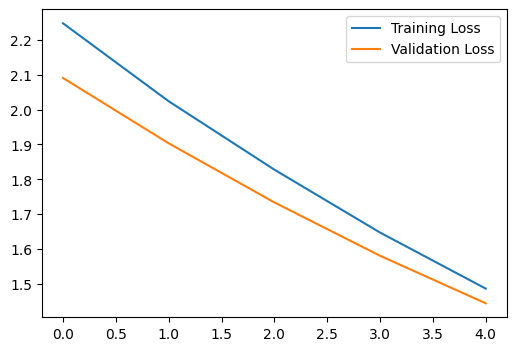

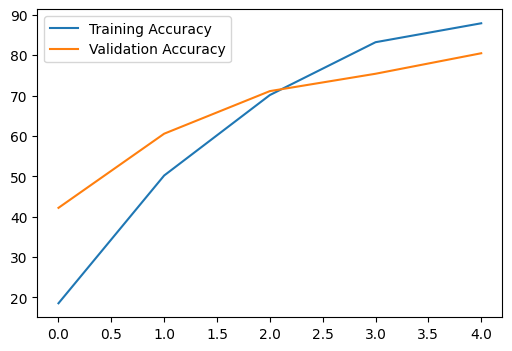

In [11]:

X_train, y_train = extract_features(resnet_model, train_loader, cache_path=f'{RUN_DIR}/features/baseline_train.pt')
X_val, y_val = extract_features(resnet_model, val_loader, cache_path=f'{RUN_DIR}/features/baseline_val.pt')

baseline_head, baseline_results = train_head_on_features(X_train, y_train, X_val, y_val, NUM_CLASSES)

resnet_model.fc = baseline_head
test_and_report(resnet_model, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(baseline_results)

save_checkpoint(baseline_head.state_dict(), 'baseline_head')

**Analytical Question 1.1:** Why is it unnecessary (and impractical) to train ResNet-152 from scratch on small datasets? What does freezing most of the network tell us about the transferability of features?

# Why training from scratch is impractical here, quantitatively.

**Parameter to Sample Mismatch:**

The CIFAR-10 subset $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ used through out this experimentation has a size $N = 8{,}000$ images across $C = 10$ classes, whereas the ResNet-152 has declared $P = 60{,}192{,}808$ backbone parameters and $58{,}164{,}298$ parameters overall. Thus the paramter to the sample ratio is:

$$\rho = \frac{P}{N} = \frac{60{,}192{,}808}{8{,}000} \approx 7{,}524 : 1$$

**Optimization & Generalization Bounds:**
Any given model when trained from scratch tries to optimze weights $\Theta$ via the Empirical Rick Minimization (ERM) given as:

$$\min_{\Theta} \mathcal{R}_{\text{emp}}(\Theta) = \frac{1}{N}\sum_{i=1}^N \mathcal{L}(f(\mathbf{x}_i; \Theta), y_i)$$

Since in our case $P \gg N$, thus the system is severely underdetermined, has way too many solutions and not enough data to restrict it. With roughly $7,500$ free parameters per training instance, thus during gradient descent the model has an excessive degree of freedom to memorize sample specific feature rather then learning the semantic boundaries, and overfit quickly.

As per statistical generalization bounds the true risk $\mathcal{R}(\Theta)$ and the emperical Rademacher complexity $\hat{\mathcal{R}}_N(\mathcal{F})$:

$$\underbrace{\mathcal{R}(\Theta)}_{\text{Real-World Error}} \le \underbrace{\mathcal{R}_{\text{emp}}(\Theta)}_{\text{Training Error}} + \underbrace{2\hat{\mathcal{R}}_N(\mathcal{F})}_{\text{Complexity Penalty}} + \underbrace{\mathcal{O}\left(\sqrt{\frac{\ln(1/\delta)}{N}}\right)}_{\text{Sample Noise / Uncertainty}}$$

This explains that for an unconstrained deep model like ResNet-152 $\hat{\mathcal{R}}_N(\mathcal{F})$ is very large. With exteremly limited number of training samples $\mathcal{R}_{\text{emp}}(\Theta)$ will quickly reach to $0$ the high complexity penalty pushes the $\mathcal{R}(\Theta)$ error bound up. To control it one will either need massive data ($N \sim 10^6$)  or reduce the parameter space by freezing the model weights

Additionally, training from scratch would mean that the model has to rediscover the entier features hierarchy like edges, textures object level parts and shapes and purely for the given $8000$ samples with minimal gurrantte of converges and then generalization.

More training such a large network will also result is wasted computation to just relearn what ResNet-152 has already learnt.

**Why Training from Scratch isUnnecessary:** ResNet-152 was pretrained on the ImageNet-1k dataset with  ($N_{\text{pre}} \approx 1.28 \times 10^6$, $C_{\text{pre}} = 1000$) with the objective function:

$$\Theta_{\text{pre}} = \arg\min_{\Theta} \frac{1}{N_{\text{pre}}} \sum_{j=1}^{N_{\text{pre}}} \mathcal{L}\left( g\big(\Phi(\mathbf{x}_j; \Theta)\big), y_j \right)$$

where $g(\cdot)$ the linear classifier, and $\Phi(\cdot; \Theta)$ are the convolutional and pooling layers from conv1 through
the avg pool.

When these pretrain weigths are imported, while removing the orginal ResNet classification head $g(\cdot)$, the convolutional backbone just acts as a non lieaner feature extraction engine:

$$\Phi_{\Theta_{\text{pre}}}: \mathcal{X} \subset \mathbb{R}^{3 \times 224 \times 224} \to \mathcal{Z} \subset \mathbb{R}^{2048}$$

Beacure the low-level and high-level visual features like edges, textures, parts and shapes are universal across natural images therefore relearning $\Theta$ from a dataset substantially smaller is unnecessary and redundant. When we know that $\Phi_{\Theta_{\text{pre}}}$ has already learned these fundamental structures.

**Feature Transferability: Linear Probe Analysis**

Freezing backbone of the model using ($\texttt{requires\_grad = False}$) and then training it only for the final classification layer $(\mathbf{W}, \mathbf{b}) \in \mathbb{R}^{10 \times 2048} \times \mathbb{R}^{10}$ just changes the training into optimizing to find the hyperplane $\mathcal{Z}$ which linearly separates the unseen CIFAR-10 classes.

This can be seen emperically, when trainined only $20,490$ paramters for just 5 epochs achives $~82\%$ Test Accuracy. The training accuracy increases steadliy from $18.55\% \to 87.89\%$  $~87.89\%$ and the class level metrics do show high separation, showing that generic ImageNet features able to linearly separate the CIFAR-10 classes in the 2048-d feature space $\Phi_{\Theta_{\text{pre}}}(\mathbf{x})$ without updating a single convolutional weight

| Backbone Weights ($\Phi$) | Trainable Layer | Trainable Parameters | CIFAR-10 Test Accuracy | Final Test Loss |
| :--- | :--- | :--- | :--- | :--- |
| **ImageNet-Pretrained ($\Theta_{\text{pre}}$)** | Linear Head (`fc`) | $20{,}490$ | **$81.95\%$** | $1.4627$ |
| **Randomly Initialized ($\Theta_{\text{rand}}$)** | Linear Head (`fc`) | $20{,}490$ | **$10.30\%$ (Chance)** | $1.18 \times 10^9$ |

## 2. Residual Connections in Practice

**Analytical Question 1.2:** How do skip connections change gradient flow in
very deep networks? What happens to convergence speed and performance when
residuals are removed?

### Residual Formulation & Gradient Flow

A standard residual connnection with the input $x$ and the output $y$ is given as:

$$\mathbf{y} = \mathcal{F}(\mathbf{x}, \{\mathbf{W}_i\}) + \mathbf{x}$$

where $F$ is could be a linear transformation or as in case a parameterized convolutional transformation.

The gradient of the Loss $\mathcal{L}$ w.r.t to the input $x$ is:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{x}} = \frac{\partial \mathcal{L}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \frac{\partial \mathcal{L}}{\partial \mathbf{y}} \left( \frac{\partial \mathcal{F}}{\partial \mathbf{x}} + \mathbf{I} \right) = \frac{\partial \mathcal{L}}{\partial \mathbf{y}} \frac{\partial \mathcal{F}}{\partial \mathbf{x}} + \frac{\partial \mathcal{L}}{\partial \mathbf{y}}$$

**Direct Shortcut ($+\mathbf{I}$):** This additive identity $\mathbf{I}$ guaranttee an uninterrupted direct highway for the gradient during back propogation to the earlier layers irrespective of how small the gradient $\frac{\partial \mathcal{F}}{\partial \mathbf{x}}$ becomes.

**Without the Skip Connection:** without the direct identity connection the gradient gets reduced to formulation:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{x}} = \frac{\partial \mathcal{L}}{\partial \mathbf{y}} \frac{\partial \mathcal{F}}{\partial \mathbf{x}}$$

In very deep netwroks like ResNet-152, during back propogation the sequential multiplications of these Jacobinas $\frac{\partial \mathcal{F}}{\partial \mathbf{x}}$ when have the singlar values $< 1$ lead to exponential vanishing of gradients, thus drastically reducing the models capability to learn.

### Skip Connection Ablation Analysis

When the skip connections were disabled in selected blocks the impact heavily depends on the block's role and location for which the skip connection is removed.

| Architecture Variant | Trainable Head Params | Val Acc (Plateau Epoch) | Test Accuracy | Feature Norm ($\mu \pm \sigma$) | Final Test Loss |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Intact Baseline** | $20{,}490$ | $80.47\%$ (Epoch 5) | **$81.95\%$** | $15.16 \pm 2.93$ | $1.4627$ |
| **Ablated `layer3[0]` (Transition)** | $20{,}490$ | $64.20\%$ (Epoch 3) | **$64.10\%$** | $14.15 \pm 1.19$ | $1.0941$ |
| **Ablated `layer3[10]` (Interior)** | $20{,}490$ | $21.80\%$ (Epoch 4) | **$22.35\%$** | $3.38 \pm 0.31$ | $2.2793$ |


**Transition Block Ablation (layer3[0], Projection Shortcut):**
When skip connection is removed from the layer3[0] of the ResNet-152 model, its creates a local disruption at that point. The folowing were observed:

  * Minor Performance Hit: Test accuracy drops from $81.95\% \to 64.10\%$ (a $-17.85\%$ penalty).
  * Feature Norms: Feature norms still remained relatively stable ($\text{mean}: 15.16 \to 14.15$, $\text{std}: 2.93 \to 1.19$).
  * Mechanism: While removing this downsample shortcut creates a local bottleneck by disrupting the spatial resultions, however, the remaining 35 subsequent blocks in layer3 have intact identity connections, allowing the network to partially absorb and recover from the distortion.

**Interior Block Ablation (layer3[10], Identity Shortcut):**
When skip connection is removed from the layer3[10] of the ResNet-152 model the network observed a severe performance hit. The folowing were observed:

* Massive Performance Hit: The test accuracy collapses to $22.35\%$ (barely above the $10.0\%$ random chance baseline).
* Feature Representation Collapse: The feature vector norm collapses by $\sim 4.5\times$ ($\text{mean}: 15.16 \to 3.38$) and variance collapses by $\sim 9.5\times$ ($\text{std}: 2.93 \to 0.31$).
* Mechanism (BatchNorm Desynchronization): During the pretraining, all 25 following blocks learned the fixed normalization statistics ($\mu, \sigma^2$). The model is expecting the full residual sum, however, cutting the skip connection simply starve these downstream network layers of the expected strong single strenght. Thus triggering a cascading effect that destroys the feature representations collapse by over $4.5\times$ ($\text{mean norm}: 15.16 \to 3.38$). This results in an irrecoverable class information loss for the network and plumeting accuracy down to ($22.35\%$).


**Convergence speed:** Without any ablations the network moves to convergence through Epoch 5 becasue it has highly rich feature represntation through its pretrained weights and is able to produce fine grained class boundaries for the linear classification terminal to fit.

However, with the skip connection removed from either layer, layer3[0] or layer3[10] the network accuracy platuea as early as the 3rd epoch at substantially very low accuracy ceilings becasue the representations are degraded or just collapsed and the models linear classifier quickly reaches the limit of what is can extract.


In [12]:
import types

def bottleneck_forward_no_skip(self, x):

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)
    out = self.relu(out)

    out = self.conv3(out)
    out = self.bn3(out)
    out = self.relu(out)

    return out


def build_ablated_resnet(ablate_specs, verbose=True):

    model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(DEVICE)
    for p in model.parameters():
        p.requires_grad = False
    model.eval()

    for layer_name, block_idx in ablate_specs:
        block = getattr(model, layer_name)[block_idx]
        block.forward = types.MethodType(bottleneck_forward_no_skip, block)

        if verbose:
            role = "transition" if block.downsample is not None else "interior"
            print(f"disabled skip connection: {layer_name}[{block_idx}]  ({role} block)")

    return model

In [13]:

resnet_transition_ablated = build_ablated_resnet([("layer3", 0)])
resnet_interior_ablated = build_ablated_resnet([("layer3", 10)])

disabled skip connection: layer3[0]  (transition block)
disabled skip connection: layer3[10]  (interior block)


baseline            feature norm: mean=15.16 std=2.93
transition-ablated  feature norm: mean=14.15 std=1.19
Epoch: 1/5 | Train Loss: 1.8352, Train Acc: 42.01% | Val Loss 1.52% Val Acc:52.25%
Epoch: 2/5 | Train Loss: 1.4102, Train Acc: 55.26% | Val Loss 1.32% Val Acc:58.55%
Epoch: 3/5 | Train Loss: 1.2524, Train Acc: 61.36% | Val Loss 1.21% Val Acc:62.20%
Epoch: 4/5 | Train Loss: 1.1568, Train Acc: 63.85% | Val Loss 1.15% Val Acc:63.15%
Epoch: 5/5 | Train Loss: 1.0931, Train Acc: 65.26% | Val Loss 1.09% Val Acc:64.20%
------------------------------
FINAL TEST RESULT
Test Loss: 1.0941
Test Accuracy: 64.10%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.76      0.65      0.70       221
  automobile       0.81      0.70      0.75       222
        bird       0.67      0.55      0.60       195
         cat       0.48      0.54      0.51       206
        deer       0.56      0.62      0.59       192
       

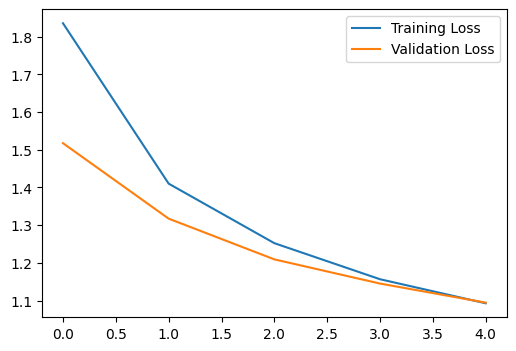

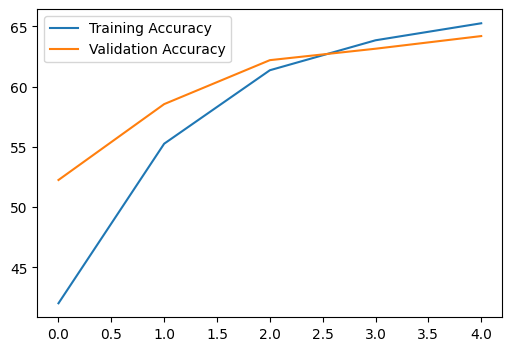

In [14]:

X_train_trans, y_train_trans = extract_features(resnet_transition_ablated, train_loader, cache_path=f'{RUN_DIR}/features/ablate_transition_train.pt')
X_val_trans, y_val_trans = extract_features(resnet_transition_ablated, val_loader, cache_path=f'{RUN_DIR}/features/ablate_transition_val.pt')


baseline_norms = X_train.norm(dim=1)
trans_norms = X_train_trans.norm(dim=1)

print(f"baseline            feature norm: mean={baseline_norms.mean():.2f} std={baseline_norms.std():.2f}")
print(f"transition-ablated  feature norm: mean={trans_norms.mean():.2f} std={trans_norms.std():.2f}")

transition_head, transition_results = train_head_on_features(X_train_trans, y_train_trans, X_val_trans, y_val_trans, NUM_CLASSES)

resnet_transition_ablated.fc = transition_head
transition_test_loss, transition_test_acc, _, _ = test_and_report(resnet_transition_ablated, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(transition_results)

save_checkpoint(transition_head.state_dict(), 'transition_ablated_head')

baseline           feature norm: mean=15.16 std=2.93
interior-ablated   feature norm: mean=3.38 std=0.31
Epoch: 1/5 | Train Loss: 2.3024, Train Acc: 10.99% | Val Loss 2.30% Val Acc:16.95%
Epoch: 2/5 | Train Loss: 2.2960, Train Acc: 11.14% | Val Loss 2.29% Val Acc:9.80%
Epoch: 3/5 | Train Loss: 2.2908, Train Acc: 17.32% | Val Loss 2.29% Val Acc:19.65%
Epoch: 4/5 | Train Loss: 2.2856, Train Acc: 21.73% | Val Loss 2.28% Val Acc:20.95%
Epoch: 5/5 | Train Loss: 2.2805, Train Acc: 23.24% | Val Loss 2.28% Val Acc:21.80%
------------------------------
FINAL TEST RESULT
Test Loss: 2.2793
Test Accuracy: 22.35%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.58      0.06      0.11       221
  automobile       0.25      0.23      0.24       222
        bird       0.00      0.00      0.00       195
         cat       0.00      0.00      0.00       206
        deer       0.30      0.14      0.19       192
         do

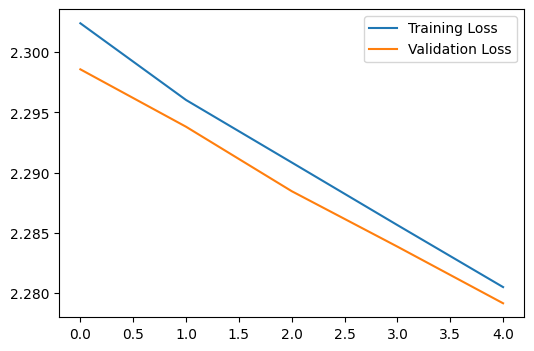

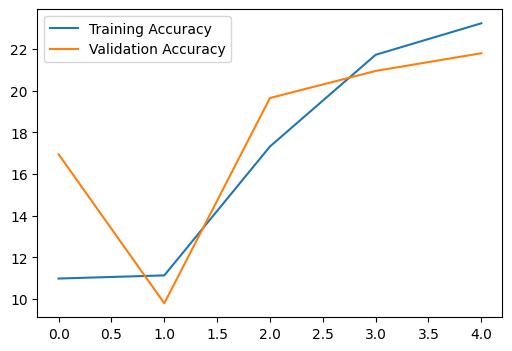

In [15]:
X_train_int, y_train_int = extract_features(resnet_interior_ablated, train_loader, cache_path=f'{RUN_DIR}/features/ablate_interior_train.pt')
X_val_int, y_val_int = extract_features(resnet_interior_ablated, val_loader, cache_path=f'{RUN_DIR}/features/ablate_interior_val.pt')

int_norms = X_train_int.norm(dim=1)
print(f"baseline           feature norm: mean={baseline_norms.mean():.2f} std={baseline_norms.std():.2f}")
print(f"interior-ablated   feature norm: mean={int_norms.mean():.2f} std={int_norms.std():.2f}")

interior_head, interior_results = train_head_on_features(X_train_int, y_train_int, X_val_int, y_val_int, NUM_CLASSES)

resnet_interior_ablated.fc = interior_head
interior_test_loss, interior_test_acc, _, _ = test_and_report(resnet_interior_ablated, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(interior_results)

save_checkpoint(interior_head.state_dict(), 'interior_ablated_head')

variant                           final_train_acc  final_val_acc   test_acc   epoch_to_plateau
baseline                                    87.89          80.47      81.95                  5
transition-ablated layer3[0]                65.26          64.20      64.10                  3
interior-ablated layer3[10]                 23.24          21.80      22.35                  4


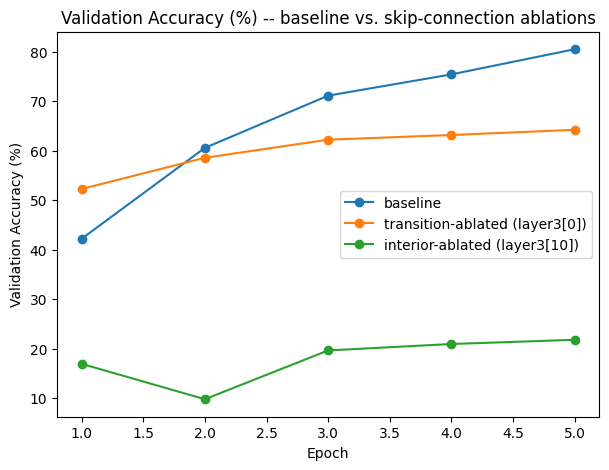

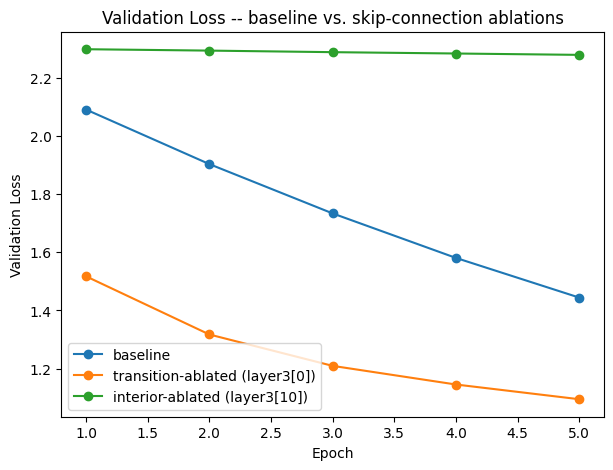

In [16]:

baseline_test_loss, baseline_test_acc = evaluate(resnet_model, test_loader, nn.CrossEntropyLoss())

def epoch_to_plateau(val_acc_list, tolerance=2.0):

    final = val_acc_list[-1]

    for i, acc in enumerate(val_acc_list):
        if final - acc <= tolerance:
            return i + 1

    return len(val_acc_list)

summary_rows = [
    ("baseline",                     baseline_results,   baseline_test_acc),
    ("transition-ablated layer3[0]", transition_results, transition_test_acc),
    ("interior-ablated layer3[10]",  interior_results,   interior_test_acc),
]

print(f"{'variant':32s} {'final_train_acc':>16s} {'final_val_acc':>14s} {'test_acc':>10s} {'epoch_to_plateau':>18s}")
for name, results, test_acc in summary_rows:
    print(f"{name:32s} {results[TRAIN_ACC][-1]:16.2f} {results[VAL_ACC][-1]:14.2f} {test_acc:10.2f} {epoch_to_plateau(results[VAL_ACC]):18d}")

def plot_comparison(results_dict, metric_key, ylabel):
    plt.figure(figsize=(7, 5))
    for label, results in results_dict.items():
        plt.plot(range(1, len(results[metric_key]) + 1), results[metric_key], marker='o', label=label)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} -- baseline vs. skip-connection ablations")
    plt.legend()
    plt.show()

comparison_results = {
    "baseline": baseline_results,
    "transition-ablated (layer3[0])": transition_results,
    "interior-ablated (layer3[10])": interior_results,
}
plot_comparison(comparison_results, VAL_ACC, "Validation Accuracy (%)")
plot_comparison(comparison_results, VAL_LOSS, "Validation Loss")

## 3. Feature Hierarchies and Representations
(a) Collect features from early, middle, and late layers of the network.

(b) Visualize these features using dimensionality reduction (t-SNE or UMAP).

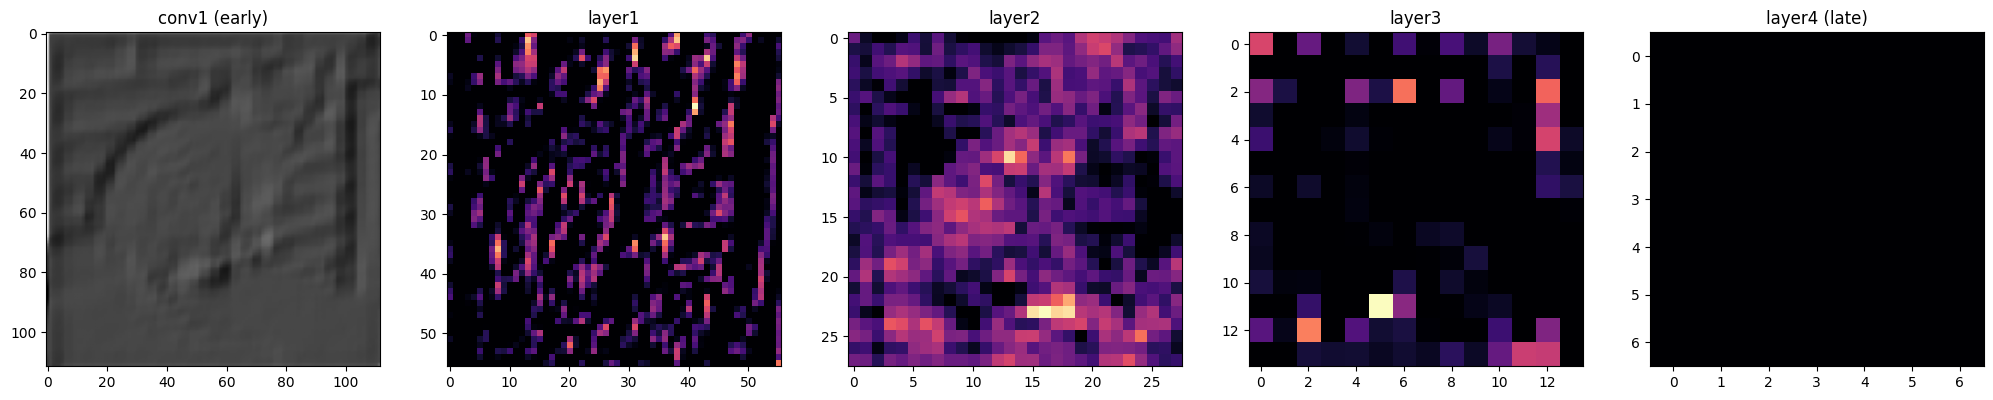

In [17]:

data_iter = iter(train_loader)
images, labels = next(data_iter)
img = images[0].unsqueeze(0).to(DEVICE)

resnet_model.eval()
with torch.no_grad():
    early_features = resnet_model.conv1(img)

    x = resnet_model.maxpool(resnet_model.relu(resnet_model.bn1(early_features)))
    x = resnet_model.layer1(x)
    layer1_features = x

    x = resnet_model.layer2(x)
    layer2_features = x

    x = resnet_model.layer3(x)
    layer3_features = x
    layer4_features = resnet_model.layer4(x)

fig, ax = plt.subplots(1, 5, figsize=(25, 5))
ax[0].imshow(early_features[0, 0].cpu(), cmap='gray'); ax[0].set_title("conv1 (early)")
ax[1].imshow(layer1_features[0, 0].cpu(), cmap='magma'); ax[1].set_title("layer1")
ax[2].imshow(layer2_features[0, 0].cpu(), cmap='magma'); ax[2].set_title("layer2")
ax[3].imshow(layer3_features[0, 0].cpu(), cmap='magma'); ax[3].set_title("layer3")
ax[4].imshow(layer4_features[0, 0].cpu(), cmap='magma'); ax[4].set_title("layer4 (late)")

plt.show()

In [18]:

activation_taps = {}

def make_hook(name):

    def hook(module, input, output):
        activation_taps[name] = output.detach()

    return hook

tap_layers = {
    "early": resnet_model.layer1,
    "middle": resnet_model.layer3,
    "late": resnet_model.avgpool,
}

handles = [layer.register_forward_hook(make_hook(name)) for name, layer in tap_layers.items()]

resnet_model.eval()
with torch.no_grad():
    sample_images, sample_labels = next(iter(test_loader))
    _ = resnet_model(sample_images.to(DEVICE))

for name, tensor in activation_taps.items():
    print(f"{name:8s} shape: {tuple(tensor.shape)}")

for h in handles:
    h.remove()

early    shape: (64, 256, 56, 56)
middle   shape: (64, 1024, 14, 14)
late     shape: (64, 2048, 1, 1)


In [19]:

multistage_feats = collect_multistage_features(resnet_model, test_loader, max_samples=1000)

for stage in ["early", "middle", "late"]:
    print(f"{stage:8s} feature shape: {tuple(multistage_feats[stage].shape)}")

early    feature shape: (1000, 256)
middle   feature shape: (1000, 1024)
late     feature shape: (1000, 2048)


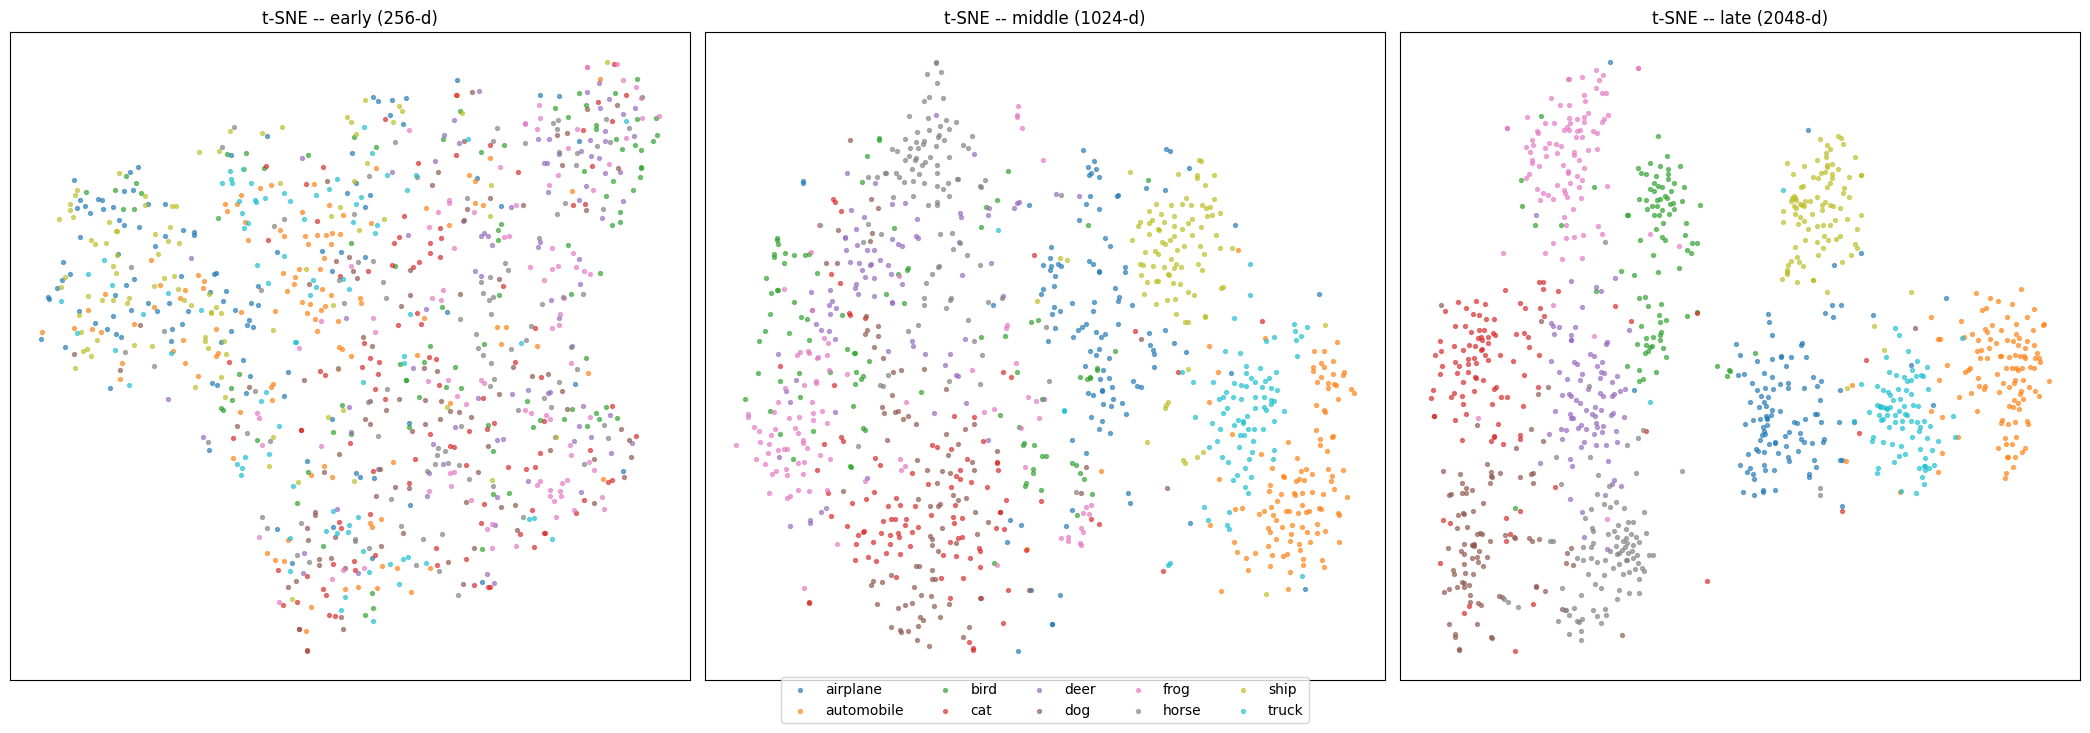

In [20]:

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, stage in zip(axes, ["early", "middle", "late"]):
    coords = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(multistage_feats[stage].numpy())

    dim = multistage_feats[stage].shape[1]
    plot_class_scatter(ax, coords, multistage_feats["labels"], classes_cifar, f"t-SNE -- {stage} ({dim}-d)")

fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

**Analytical Question 1.3:** How does class separability evolve across layers? What differences can you observe between low-level and high-level representations?

The three t-SNE panels (early = `layer1`, 256-d; middle = `layer3`,
1024-d; late = `avgpool`, 2048-d; 1000 test images) show a clear
progression of feature representation across the network depth.

- **Early Stage (layer 1):** classes are overlapping and completely intermixed, with no visible cluster structure at all.
- **Middle Stage (layer 3):** partial features and structures start to emerges. Objects like airplane, automobile, truck begin separating out on one side of the plot, while several animal classes (cat, dog, deer, horse) still remain more entangled with each other.
- **Late layer (avgpool):** At this layer we get sementically distinct clusters and hierarchy. Ten visually isolated and tight cluster form, with the "vehicle" group like airplane, automobile, truck sitting close together on the right side of the t-SNE plot and the "animal" region (cat, dog, deer, horse) grouped together, not as tight as the vehicles groups, but still with clear enough separation.


**The Receptive Field Growth & Spatial Invariance:**

Raw Pixels (150,528-d) ──► layer1 (256-d) ──► layer3 (1024-d) ──► avgpool (2048-d)
[Low-Level / Non-Linear]    (Local Edges)     (Parts & Motifs)   [High-Level / Linearly Separable]


* Early Stage: For a given input $\mathbf{x} \in \mathbb{R}^{3 \times 224 \times 224}$ , the early convolution layeers perform local operations over tiny receptive field ($\approx 7 \times 7$ to $11 \times 11$ pixels). These filters only capture the local features like edge gradients and color, i.e. model can only tell if thats curve, line etc.

* Middle Stage: Zoom out slighly via the successful convolutions and residual blocks, this expands the effective receptive field to cover sub regions of the image. This allows models to learn the intermediate channels to compose basic edges into more structural parts like wheels, limbs, starting a coarse separation between the class features.

* Late Stage: At this stage the networks effective receptive field covers the entire $224 \times 224$ input space. The Global Average Pooling (avgpool) layer collapses the remaining $7 \times 7$ spatial grid into a single vector:

$$\mathbf{z}_{\text{late}} = \frac{1}{H \times W}\sum_{h=1}^H \sum_{w=1}^W \Phi_{\text{conv}}(\mathbf{x})_{h, w} \in \mathbb{R}^{2048}$$

This stage make model learn the global compositions of the target object . It discards absolute spatial position while preserving semantic presence, projecting the input onto invariant, linearly separable class manifolds.

| Stage | Feature Tensor Shape | Feature Vector Dimension | Qualitative Separability | Primary Encoded Information |
| :--- | :--- | :--- | :--- | :--- |
| **Early (`layer1`)** | $(N, 256, 56, 56)$ | $256\text{-d}$ (Pooled) | Intermixed / Zero Separation | Low-level textures, edges, color gradients |
| **Middle (`layer3`)** | $(N, 1024, 14, 14)$ | $1024\text{-d}$ (Pooled) | Coarse separation (Vehicles vs. Animals) | Mid-level parts, contours, object motifs |
| **Late (`avgpool`)** | $(N, 2048, 1, 1)$ | $2048\text{-d}$ (Flattened) | 10 distinct, linearly separable clusters | High-level semantics, global class identities |

**Quantitative Alignment** The clearly separable clusters were plotted by t-SNE for the layer -4 (avgpool) and this directly reconciles with the numerical outputs from the  classification probes:

* Linear Readout Proof: When trained a model on a single linear head on the 2048-d avgpool features it achieves $81.95\%$ Test Accuracy in just 5 epochs. It quantitatively show that that the models is able to capture the global feature compositions and is also invariant to the objects spatial position in image and depicts that late features are already linearly separable without modifying any convolutional weights.

* Hierarchical Semantic Clustering: In some classes where there is certain hierarchical closeness like between cat and dog and/or between the automobile and truck . The late-stage manifold reflect in the confusion matrix results from Section 5, where cat $\to$ dog represents the highest confusion pair (23 misclassifications, cosine similarity $= 0.832$).

## 4. Transfer Learning and Generalization


Epoch: 1/5 | Train Loss: 2.2939, Train Acc: 17.36% | Val Loss 2.64% Val Acc:18.10%
Epoch: 2/5 | Train Loss: 2.1880, Train Acc: 20.91% | Val Loss 3.78% Val Acc:19.80%
Epoch: 3/5 | Train Loss: 2.1569, Train Acc: 21.52% | Val Loss 10.36% Val Acc:19.60%
Epoch: 4/5 | Train Loss: 2.1727, Train Acc: 22.14% | Val Loss 20.30% Val Acc:20.25%
Epoch: 5/5 | Train Loss: 2.1296, Train Acc: 23.20% | Val Loss 21.42% Val Acc:21.80%
------------------------------
FINAL TEST RESULT
Test Loss: 1181770166.2720
Test Accuracy: 10.30%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.00      0.00      0.00       221
  automobile       0.00      0.00      0.00       222
        bird       0.00      0.00      0.00       195
         cat       0.10      1.00      0.19       206
        deer       0.00      0.00      0.00       192
         dog       0.00      0.00      0.00       190
        frog       0.00      0.00      0.00      

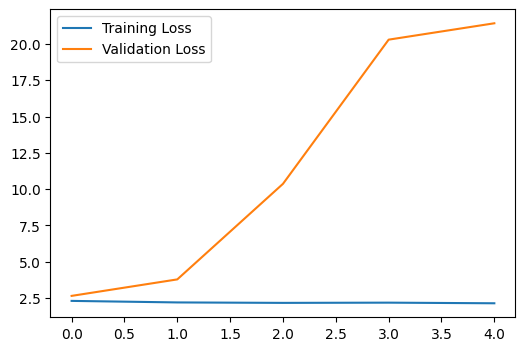

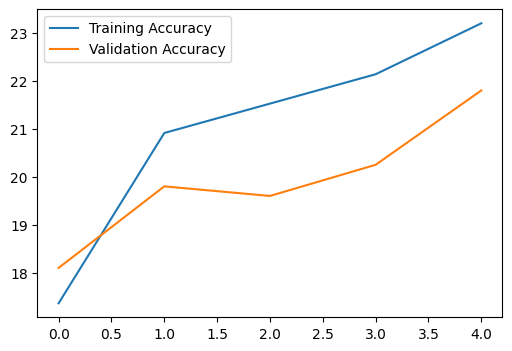

In [21]:

random_backbone = models.resnet152(weights=None).to(DEVICE)
for p in random_backbone.parameters():
    p.requires_grad = False

random_backbone.eval()

X_train_rf, y_train_rf = extract_features(random_backbone,
                                          train_loader,
                                          cache_path=f'{RUN_DIR}/features/random_frozen_train.pt')

X_val_rf, y_val_rf = extract_features(random_backbone,
                                      val_loader,
                                      cache_path=f'{RUN_DIR}/features/random_frozen_val.pt')

random_frozen_head, random_frozen_results = train_head_on_features(X_train_rf,
                                                                   y_train_rf,
                                                                   X_val_rf,
                                                                   y_val_rf,
                                                                   NUM_CLASSES,
                                                                   normalize_features=True)

random_backbone.fc = random_frozen_head

random_frozen_test_loss, random_frozen_test_acc, _, _ = test_and_report(random_backbone,
                                                                        test_loader,
                                                                        nn.CrossEntropyLoss(),
                                                                        classes_cifar)

plot_loss_acc(random_frozen_results)

save_checkpoint(random_frozen_head.state_dict(), 'random_frozen_head')

Epoch: 1/5 | Train Loss: 0.6410, Train Acc: 85.29% | Val Loss 0.18% Val Acc:94.55%
Epoch: 2/5 | Train Loss: 0.0926, Train Acc: 97.31% | Val Loss 0.18% Val Acc:94.25%
Epoch: 3/5 | Train Loss: 0.0272, Train Acc: 99.42% | Val Loss 0.17% Val Acc:94.55%
Epoch: 4/5 | Train Loss: 0.0108, Train Acc: 99.80% | Val Loss 0.18% Val Acc:94.90%
Epoch: 5/5 | Train Loss: 0.0087, Train Acc: 99.76% | Val Loss 0.19% Val Acc:95.15%
------------------------------
FINAL TEST RESULT
Test Loss: 0.1997
Test Accuracy: 94.85%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.97      0.97      0.97       221
  automobile       0.99      0.96      0.98       222
        bird       0.93      0.94      0.94       195
         cat       0.88      0.90      0.89       206
        deer       0.91      0.93      0.92       192
         dog       0.92      0.88      0.90       190
        frog       0.96      0.97      0.97       195
       

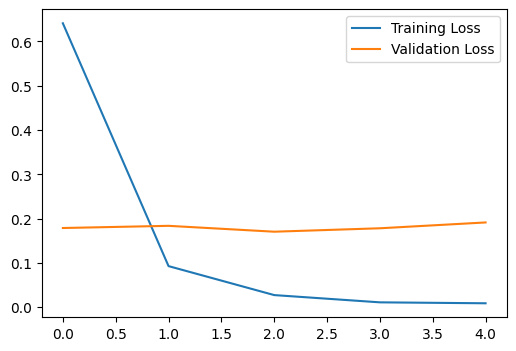

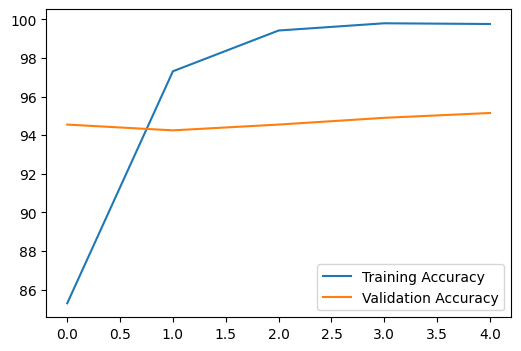

In [22]:

layer3_pretrained_base, final_block_pretrained_model = build_final_block_trainer(pretrained=True)

X_l3_train_p, y_l3_train_p = extract_stage_features(layer3_pretrained_base,
                                                    train_loader,
                                                    cache_path=f'{RUN_DIR}/features/layer3_pretrained_train.pt')

X_l3_val_p, y_l3_val_p = extract_stage_features(layer3_pretrained_base,
                                                val_loader,
                                                cache_path=f'{RUN_DIR}/features/layer3_pretrained_val.pt')

optimizer = optim.Adam(final_block_pretrained_model.parameters(), lr=1e-4)

train_loader_l3p = DataLoader(torch.utils.data.TensorDataset(X_l3_train_p, y_l3_train_p),
                              batch_size=64,
                              shuffle=True)

val_loader_l3p = DataLoader(torch.utils.data.TensorDataset(X_l3_val_p, y_l3_val_p),
                            batch_size=64,
                            shuffle=False)

final_block_pretrained_results = train_model(final_block_pretrained_model,
                                             train_loader_l3p,
                                             val_loader_l3p,
                                             nn.CrossEntropyLoss(),
                                             optimizer,
                                             num_epochs=NUM_EPOCHS)

del X_l3_train_p, y_l3_train_p, X_l3_val_p, y_l3_val_p, train_loader_l3p, val_loader_l3p
gc.collect()

layer3_pretrained_base.fc = final_block_pretrained_model.fc

final_block_pretrained_test_loss, final_block_pretrained_test_acc, _, _ = test_and_report(layer3_pretrained_base,
                                                                                          test_loader,
                                                                                          nn.CrossEntropyLoss(),
                                                                                          classes_cifar)

plot_loss_acc(final_block_pretrained_results)

save_checkpoint(final_block_pretrained_model.state_dict(), 'final_block_pretrained')

Epoch: 1/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 2/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 3/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 4/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
Epoch: 5/5 | Train Loss: nan, Train Acc: 10.07% | Val Loss nan% Val Acc:10.90%
------------------------------
FINAL TEST RESULT
Test Loss: nan
Test Accuracy: 11.05%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.11      1.00      0.20       221
  automobile       0.00      0.00      0.00       222
        bird       0.00      0.00      0.00       195
         cat       0.00      0.00      0.00       206
        deer       0.00      0.00      0.00       192
         dog       0.00      0.00      0.00       190
        frog       0.00      0.00      0.00       195
       horse       0.00      0

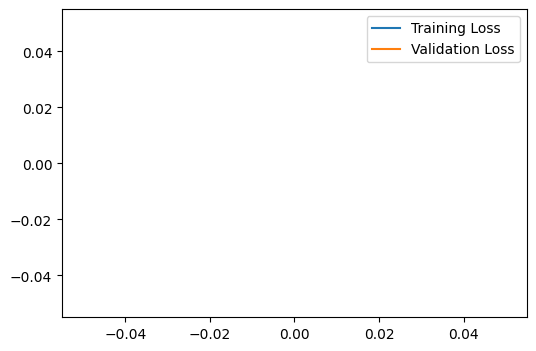

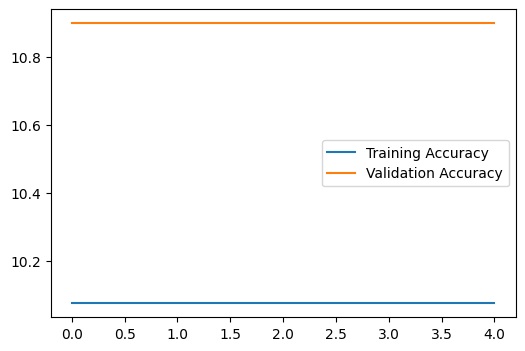

In [23]:

layer3_random_base, final_block_random_model = build_final_block_trainer(pretrained=False)

X_l3_train_r, y_l3_train_r = extract_stage_features(layer3_random_base, train_loader, cache_path=f'{RUN_DIR}/features/layer3_random_train.pt')
X_l3_val_r, y_l3_val_r = extract_stage_features(layer3_random_base, val_loader, cache_path=f'{RUN_DIR}/features/layer3_random_val.pt')

optimizer = optim.Adam(final_block_random_model.parameters(), lr=1e-3)
train_loader_l3r = DataLoader(torch.utils.data.TensorDataset(X_l3_train_r, y_l3_train_r), batch_size=64, shuffle=True)
val_loader_l3r = DataLoader(torch.utils.data.TensorDataset(X_l3_val_r, y_l3_val_r), batch_size=64, shuffle=False)

final_block_random_results = train_model(final_block_random_model, train_loader_l3r, val_loader_l3r, nn.CrossEntropyLoss(), optimizer, num_epochs=NUM_EPOCHS)

del X_l3_train_r, y_l3_train_r, X_l3_val_r, y_l3_val_r, train_loader_l3r, val_loader_l3r
gc.collect()

layer3_random_base.fc = final_block_random_model.fc
final_block_random_test_loss, final_block_random_test_acc, _, _ = test_and_report(layer3_random_base, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(final_block_random_results)

save_checkpoint(final_block_random_model.state_dict(), 'final_block_random')

Epoch: 1/3 | Train Loss: 2.1311, Train Acc: 33.27% | Val Loss 1.88% Val Acc:57.90%
Epoch: 2/3 | Train Loss: 1.3155, Train Acc: 76.08% | Val Loss 0.74% Val Acc:84.90%
Epoch: 3/3 | Train Loss: 0.4911, Train Acc: 88.76% | Val Loss 0.34% Val Acc:91.45%
------------------------------
FINAL TEST RESULT
Test Loss: 0.3189
Test Accuracy: 92.30%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.91      0.96      0.93       221
  automobile       0.98      0.96      0.97       222
        bird       0.91      0.88      0.90       195
         cat       0.89      0.85      0.87       206
        deer       0.85      0.90      0.88       192
         dog       0.89      0.93      0.91       190
        frog       0.91      0.93      0.92       195
       horse       0.96      0.90      0.93       210
        ship       0.96      0.96      0.96       189
       truck       0.97      0.96      0.96       180

    accura

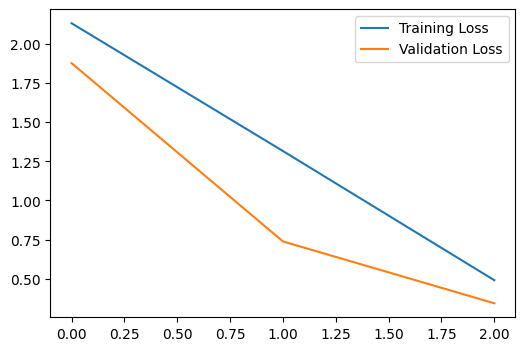

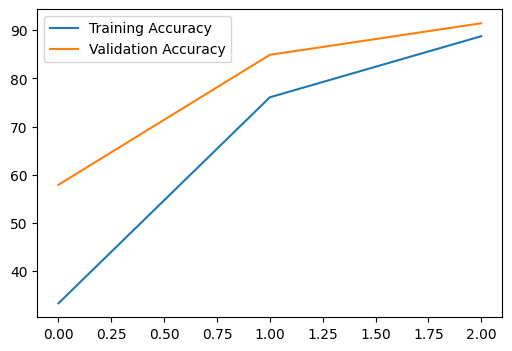

In [24]:

full_backbone_model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT).to(DEVICE)

full_backbone_model.fc = nn.Linear(full_backbone_model.fc.in_features, NUM_CLASSES).to(DEVICE)

for p in full_backbone_model.parameters():
    p.requires_grad = True

full_backbone_model = full_backbone_model.to(DEVICE)

FULL_BACKBONE_EPOCHS = min(NUM_EPOCHS, 3)

optimizer = optim.Adam(full_backbone_model.parameters(), lr=1e-5)

scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))

full_backbone_results = train_model(full_backbone_model,
                                    train_loader,
                                    val_loader,
                                    nn.CrossEntropyLoss(),
                                    optimizer,
                                    num_epochs=FULL_BACKBONE_EPOCHS,
                                    scaler=scaler)

full_backbone_test_loss, full_backbone_test_acc, _, _ = test_and_report(full_backbone_model,
                                                                        test_loader,
                                                                        nn.CrossEntropyLoss(),
                                                                        classes_cifar)
plot_loss_acc(full_backbone_results)

save_checkpoint(full_backbone_model.state_dict(), 'full_backbone_pretrained')

variant                        final_train_ac  final_val_acc   test_acc
frozen head, pretrained                 87.89          80.47      81.95
frozen head, random init                23.20          21.80      10.30
final block, pretrained                 99.76          95.15      94.85
final block, random init                10.07          10.90      11.05
full backbone, pretrained               88.76          91.45      92.30


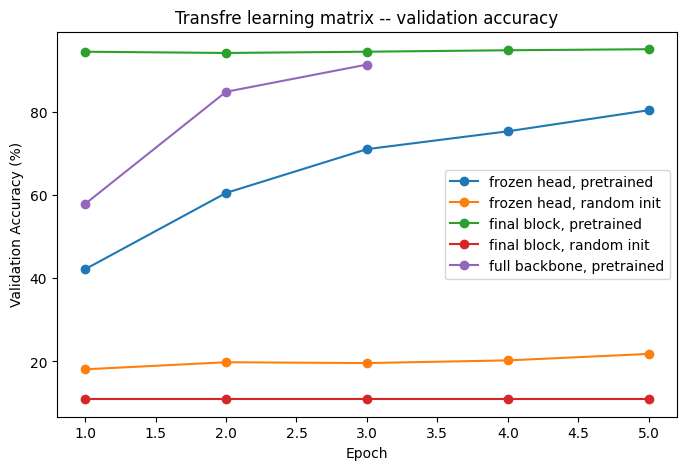

In [25]:

baseline_test_loss_s4, baseline_test_acc_s4 = evaluate(resnet_model, test_loader, nn.CrossEntropyLoss())

transfer_summary_rows = [
    ("frozen head, pretrained",   baseline_results,               baseline_test_acc_s4),
    ("frozen head, random init",  random_frozen_results,          random_frozen_test_acc),
    ("final block, pretrained",   final_block_pretrained_results, final_block_pretrained_test_acc),
    ("final block, random init",  final_block_random_results,     final_block_random_test_acc),
    ("full backbone, pretrained", full_backbone_results,          full_backbone_test_acc),
]

print(f"{'variant':28s} {'final_train_ac':>16s} {'final_val_acc':>14s} {'test_acc':>10s}")
for name, results, test_acc in transfer_summary_rows:
    print(f"{name:28s} {results[TRAIN_ACC][-1]:16.2f} {results[VAL_ACC][-1]:14.2f} {test_acc:10.2f}")

plt.figure(figsize=(8, 5))

for name, results, _ in transfer_summary_rows:
    plt.plot(range(1, len(results[VAL_ACC]) + 1), results[VAL_ACC], marker='o', label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Transfre learning matrix -- validation accuracy")

plt.legend()
plt.show()

**Analytical Question 1.4:** Which setting provides the best trade-off
between compute and accuracy? Which layers seem most transferable across
datasets, and why?

# Results, ranked by test accuracy

| Transfer Strategy | Initialized Weights | Trainable Parameters | Epochs | Test Accuracy | Test Loss |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Final Block (`layer4` + `fc`)** | Pretrained | $\sim 15\text{M}$ | 5 | **$94.85\%$** | $0.1997$ |
| **Full Backbone** | Pretrained | $\sim 60\text{M}$ | 3 | $92.30\%$ | $0.3189$ |
| **Linear Head (`fc` only)** | Pretrained | $\sim 20\text{K}$ | 5 | $81.95\%$ | $1.4627$ |
| **Final Block (`layer4` + `fc`)** | Random Init | $\sim 15\text{M}$ | 5 | $11.05\%$ (Chance) | `nan` |
| **Linear Head (`fc` only)** | Random Init | $\sim 20\text{K}$ | 5 | $10.30\%$ (Chance) | $1.18 \times 10^9$ |



**Best Trade-Off - The Final Block (layer4 + fc), Pretrained:** the highest performance was observed using the Final Block (layer4 + fc) where the ResNet-152 backbone was frozeen uptil layer 3 and pretrained weights were used. The network then trained for ResNet-152 layer 4 and the linear classification layer while maintaining significant computational efficiency

* Highest Accuracy: Reaches $94.85\%$ test accuracy, outperforming full-network fine-tuning by $+2.55\%$ and the frozen linear head by $+12.90\%$.
* Compute Efficiency via Feature Caching: As in this setup the layers from conv1 through layer3 remained frozen thus their representations only need to be computed once and cached to disk (layer3_pretrained_train.pt). During training each epoch only executes a forward/backward pass through layer4 and the fc head and bypassing the computation of the first $140+$ layers on every epoch.

### Layer Transferbility Analysis

When dealing with transfer learning, the Early to Mid layers of deep models, which are train on large datasets, extract and learn the generic and invariant visual features like edges, textures, object contours, object parts/sub-parts. This behaviour is clearly depicted in **The Final Block (layer4 + fc), Pretrained** architecture where the early 3 layers (conv1 through layer 3) of the network were frozeen, pretrained weights from ResNet-152 were used to initize and train the final layer (layer 4) of ResNet and the classification head resulting in best accuracy numbers.

* Late layers are Task-Specific: The Final Block (layer4 + fc), Pretrained** architecture out-performed by $12.90\%$ the architecture with a fully freezon backend with pretrained weights and where only the classification head needs to be trained. It also shows that task-specific specialization lives in the final residual stage, where high-level semantic manifolds are shaped to separate CIFAR-10 classes.

* Random-Initialization Baselines: In experiments where randomly initializated weights were used the benefit of pretraining is lost. As show in case of both the Frozen Head (Random) and Final Block (Random) the accuracy is crashed at $10.30\%$ and  $11.05\%$ respectively. *Its shows that the architecture depth alone yields zero downstream utility and the entire performance gain is driven by the transferable feature representations acquired during ImageNet pretraining.*


## 5. Optional Experiments
(a) Compare t-SNE vs. UMAP in representing feature separability.

(b) Analyze feature similarities between classes that ResNet tends to confuse.

(c) Compare feature quality from ResNet-152 with a shallower ResNet (e.g., ResNet-18).

In [26]:
%pip install -q umap-learn
import umap

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


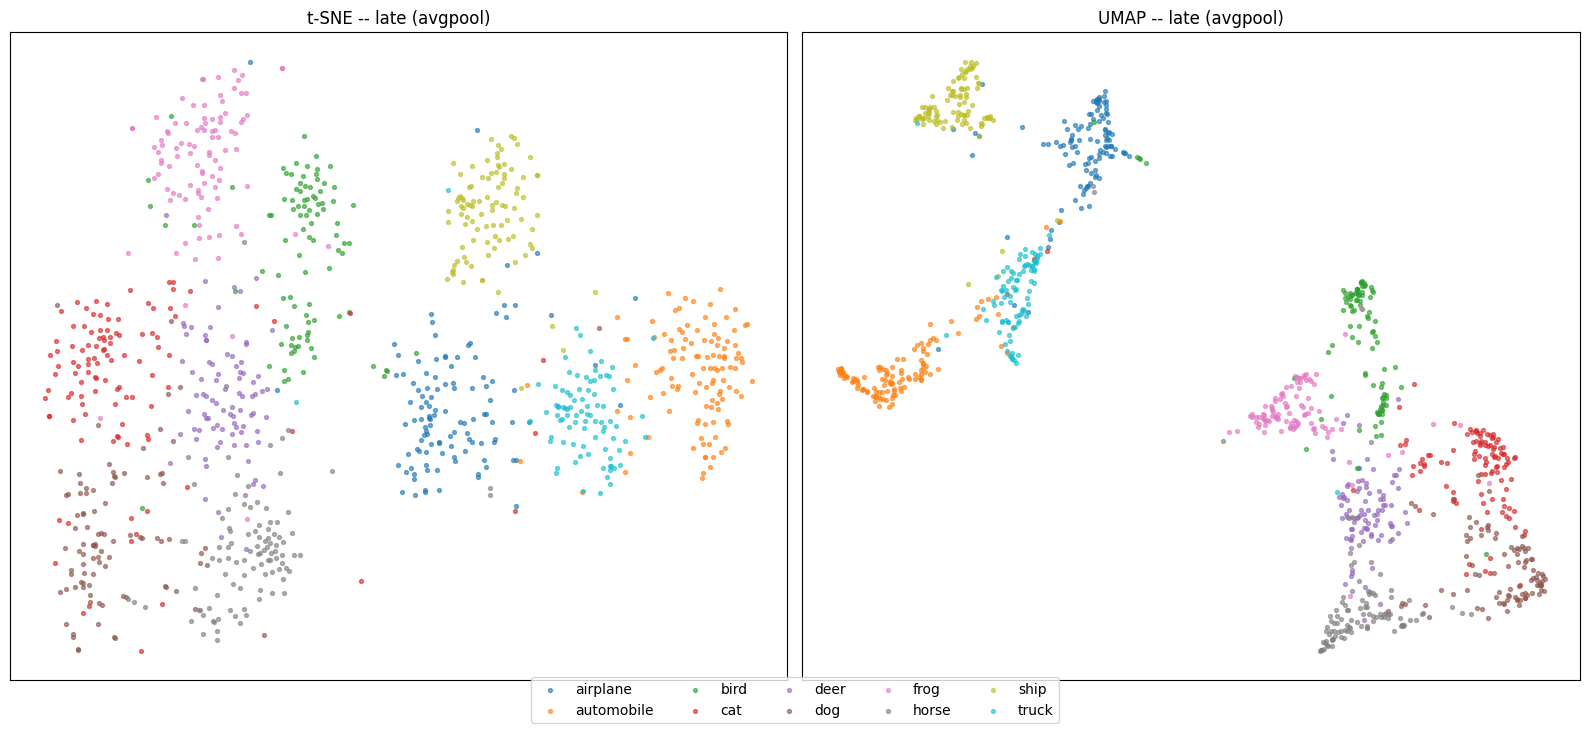

In [27]:

late_np = multistage_feats["late"].numpy()

tsne_late = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(late_np)
umap_late = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(late_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plot_class_scatter(axes[0], tsne_late, multistage_feats["labels"], classes_cifar, "t-SNE -- late (avgpool)")
plot_class_scatter(axes[1], umap_late, multistage_feats["labels"], classes_cifar, "UMAP -- late (avgpool)")

fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()

plt.show()

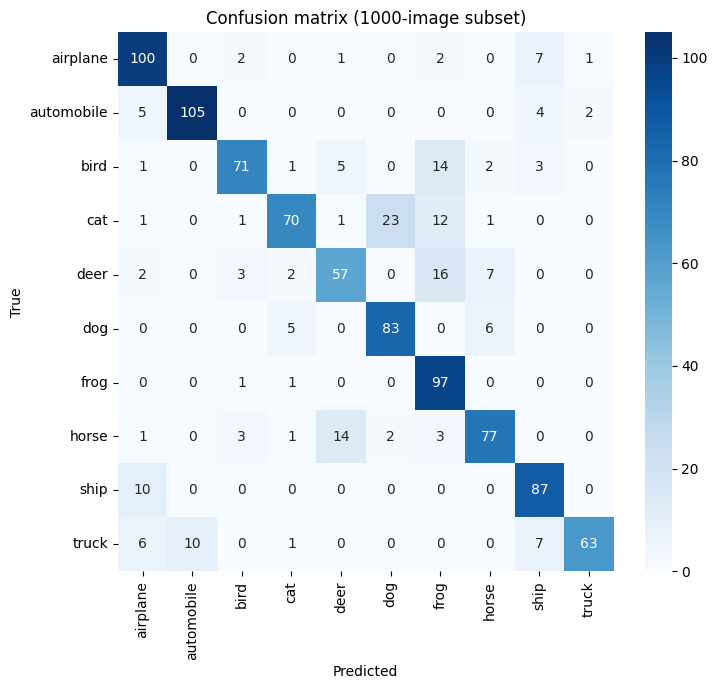

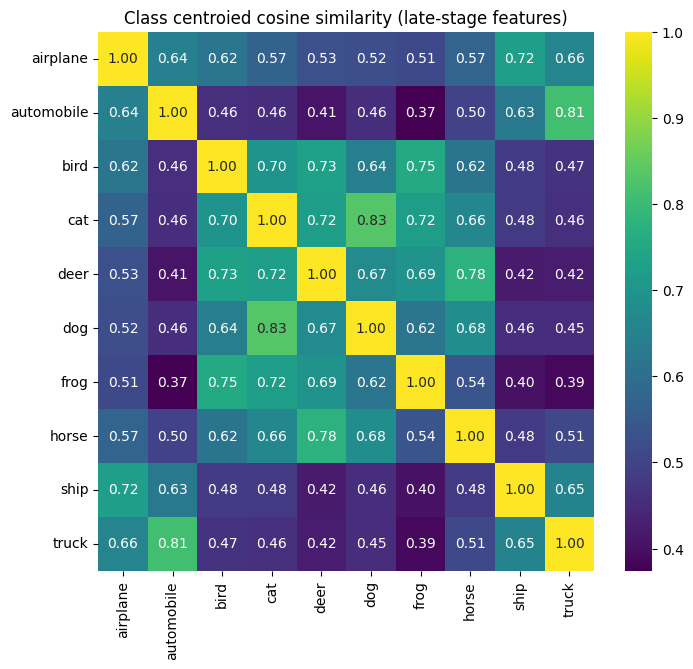

Top confused pairs (true -> predicited):
  cat          -> dog         : 23 misclassified (of 1000-sample subset), centroid cosine similarity=0.832
  deer         -> frog        : 16 misclassified (of 1000-sample subset), centroid cosine similarity=0.695
  horse        -> deer        : 14 misclassified (of 1000-sample subset), centroid cosine similarity=0.777
  bird         -> frog        : 14 misclassified (of 1000-sample subset), centroid cosine similarity=0.752
  cat          -> frog        : 12 misclassified (of 1000-sample subset), centroid cosine similarity=0.719


In [28]:

y_true_ms = multistage_feats["labels"].numpy()
y_pred_ms = multistage_feats["preds"].numpy()

cm = confusion_matrix(y_true_ms, y_pred_ms)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes_cifar, yticklabels=classes_cifar)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (1000-image subset)")
plt.show()

centroids = np.stack([late_np[y_true_ms == c].mean(axis=0) for c in range(len(classes_cifar))])
centroid_sim = cosine_similarity(centroids)

plt.figure(figsize=(8, 7))
sns.heatmap(centroid_sim, annot=True, fmt=".2f", cmap="viridis", xticklabels=classes_cifar, yticklabels=classes_cifar)
plt.title("Class centroied cosine similarity (late-stage features)")
plt.show()

cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
confused_pairs = [
    (cm_off_diag[i, j], classes_cifar[i], classes_cifar[j])
    for i in range(len(classes_cifar))
    for j in range(len(classes_cifar))
    if i != j
]
confused_pairs.sort(reverse=True)

print("Top confused pairs (true -> predicited):")
for count, true_c, pred_c in confused_pairs[:5]:
    sim = centroid_sim[classes_cifar.index(true_c), classes_cifar.index(pred_c)]
    print(f"  {true_c:12s} -> {pred_c:12s}: {count} misclassified (of {len(y_true_ms)}-sample subset), centroid cosine similarity={sim:.3f}")

Epoch: 1/5 | Train Loss: 1.5131, Train Acc: 56.02% | Val Loss 0.98% Val Acc:76.60%
Epoch: 2/5 | Train Loss: 0.7940, Train Acc: 79.97% | Val Loss 0.70% Val Acc:80.90%
Epoch: 3/5 | Train Loss: 0.6209, Train Acc: 83.11% | Val Loss 0.61% Val Acc:82.05%
Epoch: 4/5 | Train Loss: 0.5420, Train Acc: 84.55% | Val Loss 0.56% Val Acc:83.20%
Epoch: 5/5 | Train Loss: 0.4942, Train Acc: 85.80% | Val Loss 0.53% Val Acc:83.65%
------------------------------
FINAL TEST RESULT
Test Loss: 0.5020
Test Accuracy: 84.50%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.91      0.86      0.88       221
  automobile       0.94      0.93      0.93       222
        bird       0.76      0.77      0.77       195
         cat       0.81      0.68      0.74       206
        deer       0.72      0.84      0.78       192
         dog       0.78      0.79      0.78       190
        frog       0.88      0.89      0.88       195
       

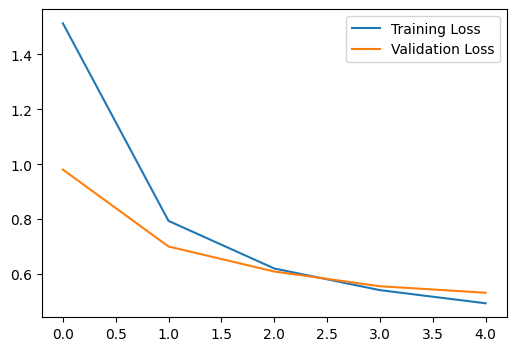

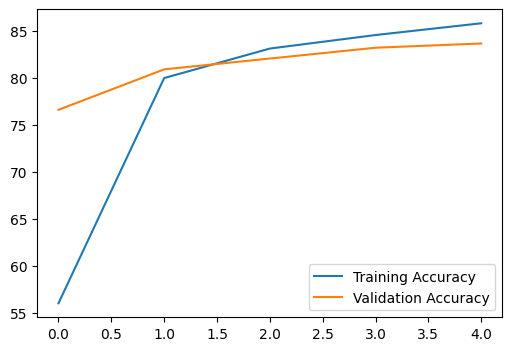

In [29]:

resnet18_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(DEVICE)
resnet18_model.eval()
for p in resnet18_model.parameters():
    p.requires_grad = False

X_train_r18, y_train_r18 = extract_features(resnet18_model, train_loader, cache_path=f'{RUN_DIR}/features/resnet18_train.pt')
X_val_r18, y_val_r18 = extract_features(resnet18_model, val_loader, cache_path=f'{RUN_DIR}/features/resnet18_val.pt')

resnet18_head, resnet18_results = train_head_on_features(X_train_r18, y_train_r18, X_val_r18, y_val_r18, NUM_CLASSES)

resnet18_model.fc = resnet18_head
resnet18_test_loss, resnet18_test_acc, _, _ = test_and_report(resnet18_model, test_loader, nn.CrossEntropyLoss(), classes_cifar)
plot_loss_acc(resnet18_results)

resnet152_params = sum(p.numel() for p in resnet_model.parameters())
resnet18_params = sum(p.numel() for p in resnet18_model.parameters())

print(f"ResNet-152: {baseline_test_acc_s4:.2f}% test acc | {resnet152_params:,} total parms")
print(f"ResNet-18 :  {resnet18_test_acc:.2f}% test acc | {resnet18_params:,} total parms")

save_checkpoint(resnet18_head.state_dict(), 'resnet18_head')

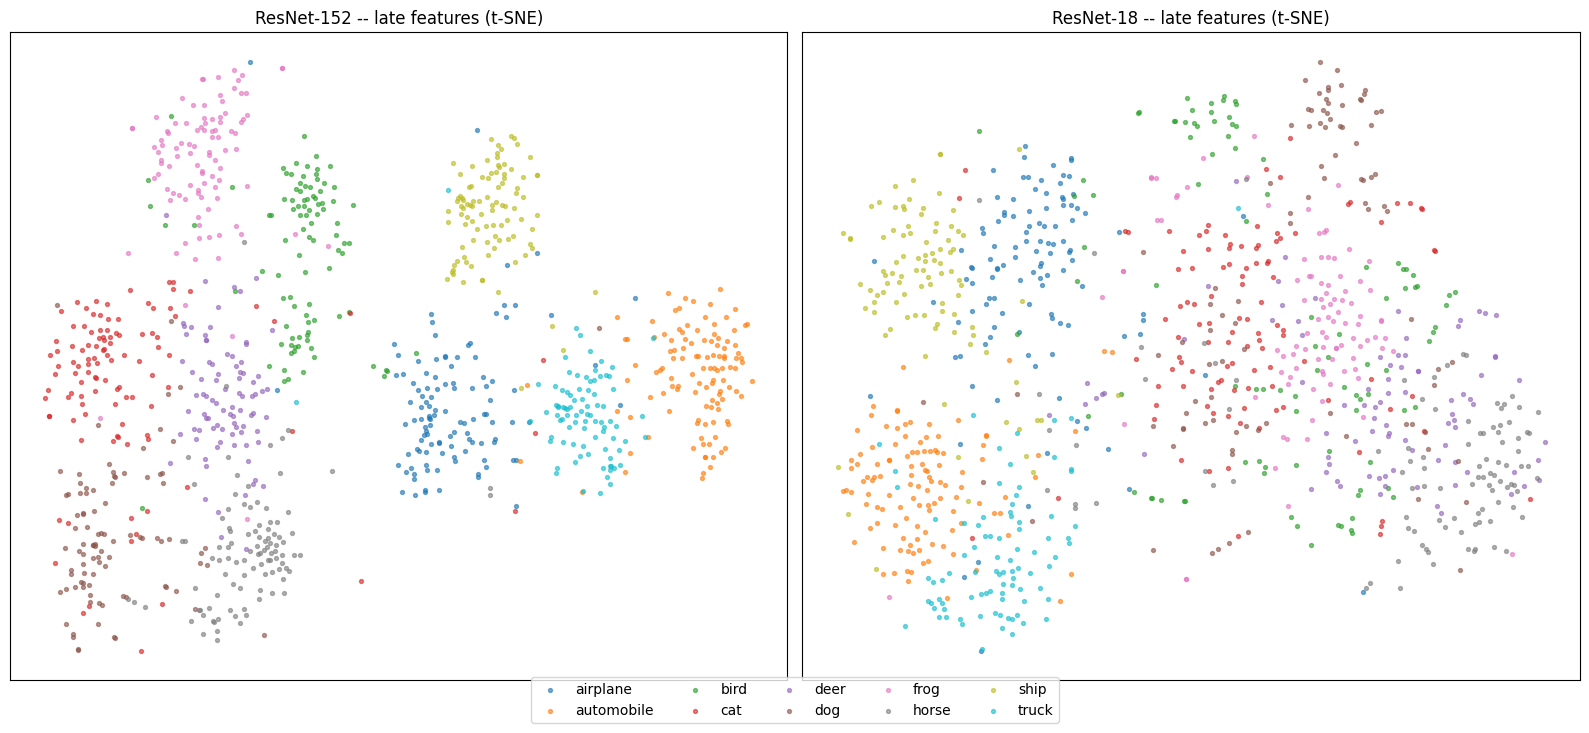

In [30]:

r18_feats = collect_multistage_features(resnet18_model, test_loader, max_samples=1000)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

coords_152 = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(multistage_feats["late"].numpy())
coords_18 = TSNE(n_components=2, perplexity=30, init="pca", random_state=42).fit_transform(r18_feats["late"].numpy())

plot_class_scatter(axes[0], coords_152, multistage_feats["labels"], classes_cifar, "ResNet-152 -- late features (t-SNE)")
plot_class_scatter(axes[1], coords_18, r18_feats["labels"], classes_cifar, "ResNet-18 -- late features (t-SNE)")

fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# Optional Experiments & Representation Analysis

### Experiment (a): Dimensionality Reduction Comparison (t-SNE vs. UMAP)

**Empirical Observation**: Both algorithms reveal 10 distinct class clusters from the 2048-d avgpool features, but their spatial layouts differ:

**t-SNE**: Prioritizes local neighborhoods, isolating individual classes into tight, equidistant spherical clusters.

**UMAP**: Better preserves global manifold topology, clearly separating the broad super-clusters—grouping mechanical vehicles (airplane, automobile, truck, ship) together on one continuum, while placing natural quadrupeds (cat, dog, deer, horse) into an adjoining semantic region.

**Significance**: Validates that ImageNet pretraining does not just create arbitrary class boundaries; it arranges the feature space into a continuous, globally coherent semantic hierarchy.

### Experiment (b): Class Confusion & Centroid Cosine Similarity Analysis

**Empirical Observation**: Cross-referencing the confusion matrix against the class centroid cosine similarities

$\cos(\mathbf{c}_i, \mathbf{c}_j) = \frac{\mathbf{c}_i \cdot \mathbf{c}_j}{\Vert{}\mathbf{c}_i\Vert{} \Vert{}\mathbf{c}_j\Vert{}}$

this directly accounts for error patterns

  * Top Error Pair:** $\text{cat} \to \text{dog}$ accounts for 23 misclassifications with the highest inter-class centroid similarity ($0.832$).
 * Secondary Confusions: $\text{horse} \to \text{deer}$ (14 errors, similarity $0.752$).

**Significance**: Confirms that model misclassifications are not random noise. They correlate directly with geometric proximity in the 2048-d representation space, proving the classifier preserves intuitive biological and morphological overlaps.

### Experiment (c): Feature Quality & Model Capacity (ResNet-152 vs. ResNet-18)

| Model Variant | Total Parameters | Feature Dimension ($d$) | CIFAR-10 Test Accuracy | Final Test Loss |
| :--- | :--- | :--- | :--- | :--- |
| **ResNet-18 (Frozen Backbone)** | $\mathbf{11{,}181{,}642}$ | $512\text{-d}$ | $\mathbf{84.50\%}$ | $\mathbf{0.5020}$ |
| **ResNet-152 (Frozen Backbone)** | $58{,}164{,}298$ | $2048\text{-d}$ | $81.95\%$ | $1.4627$ |

**Empirical Observation:** The shallower ResNet-18 achieves $+2.55\%$ higher test accuracy ($84.50\%$ vs. $81.95\%$) and a significantly lower test loss ($0.5020$ vs. $1.4627$), despite having over $5\times$ fewer parameters ($\sim 11.2\text{M}$ vs. $\sim 58.2\text{M}$).

**Significance:**
  * Resolution-Capacity Alignment: ResNet-152’s deeper hierarchy produces highly abstract, ImageNet-specialized 2048-d features. On small low-resolution inputs like CIFAR-10, an 18-layer backbone with a more compact 512-d feature space provides a more linearly separable, less over-compressed representation for a simple linear probe.
  
  * Practical Takeaway: Deeper is not always better for linear probing out-of-the-box. When target data is limited and low-resolution, shallower backbones can offer superior compute efficiency and cleaner linear transferability without needing block fine-tuning.